# fAIr predict ; minimal examples

Uses knative cold start for containers ; POST a bbox + tile URL + ONNX URI to a fAIr predict endpoint, render the returned GeoJSON over the source tiles.


In [44]:
import contextily as cx
import geopandas as gpd
import httpx

STAC = "https://stac.fair.krschap.tech/stac"
IMAGE_URI = "https://tiles.openaerialmap.org/62d85d11d8499800053796c1/0/62d85d11d8499800053796c2/{z}/{x}/{y}"
BBOX = [85.51678033745037, 27.6313353660439, 85.52323021107895, 27.637438390948745]
ZOOM = 18


def _item(coll, mid):
    r = httpx.get(f"{STAC}/collections/{coll}/items/{mid}")
    r.raise_for_status()
    return r.json()


def call_predict(model_id, params, collection="base-models"):
    item = _item(collection, model_id)
    base = item if collection == "base-models" else _item("base-models", item["properties"]["fair:base_model_id"])
    r = httpx.post(
        base["assets"]["mlm:inference-endpoint"]["href"],
        json={
            "model_uri": item["assets"]["model"]["href"],
            "image_uri": IMAGE_URI,
            "bbox": BBOX,
            "zoom": ZOOM,
            "params": params,
        },
        timeout=300,
    )
    r.raise_for_status()
    return gpd.GeoDataFrame.from_features(r.json()["features"], crs="EPSG:4326")


def plot(gdf, title):
    by_conf = "confidence" in gdf.columns
    col = "confidence" if by_conf else next((c for c in ("label", "class") if c in gdf.columns), None)
    extra = (
        {"cmap": "viridis", "vmin": 0, "vmax": 1, "legend_kwds": {"label": "confidence", "shrink": 0.6}}
        if by_conf
        else {}
    )
    ax = gdf.plot(
        column=col, legend=col is not None, edgecolor="white", linewidth=0.4, alpha=0.55, figsize=(9, 9), **extra
    )
    cx.add_basemap(ax, source=IMAGE_URI, crs=gdf.crs, zoom=ZOOM)
    ax.set_title(f"{title}  (n={len(gdf)})")
    ax.set_axis_off()
    return ax

## ResNet18 classification

In [45]:
gdf = call_predict(
    "27f6f5a6-d079-44ac-80b1-be9ff268c2cb",
    collection="local-models",
    params={"confidence_threshold": 0.5},
)
print(f"features: {len(gdf)}")
gdf.head()

HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/local-models/items/27f6f5a6-d079-44ac-80b1-be9ff268c2cb "HTTP/1.1 200 OK"
HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/base-models/items/resnet18-classification "HTTP/1.1 200 OK"
HTTP Request: POST https://resnet18-classification.predict.fair.krschap.tech/predict "HTTP/1.1 200 OK"
features: 36


,geometry,label,confidence,source
0,"POLYGON ((85.5162 27.63731, 85.51758 27.63731,...",building,0.9468,OAM-193343-110117-18.tif
1,"POLYGON ((85.5162 27.63609, 85.51758 27.63609,...",building,0.8926,OAM-193343-110118-18.tif
2,"POLYGON ((85.5162 27.63487, 85.51758 27.63487,...",building,0.9957,OAM-193343-110119-18.tif
3,"POLYGON ((85.5162 27.63366, 85.51758 27.63366,...",building,0.9732,OAM-193343-110120-18.tif
4,"POLYGON ((85.5162 27.63244, 85.51758 27.63244,...",building,0.8921,OAM-193343-110121-18.tif


<Axes: title={'center': 'resnet18-classification  (n=36)'}>

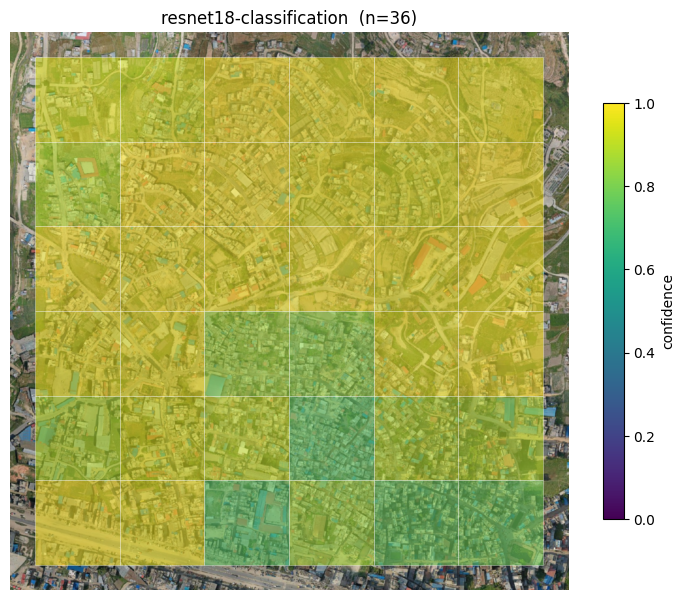

In [46]:
plot(gdf, "resnet18-classification")

## UNet segmentation

In [47]:
gdf = call_predict(
    "08e20666-f8fa-4b8a-8fe8-72661a590fd0",
    collection="local-models",
    params={"confidence_threshold": 0.5, "min_class_value": 1},
)
print(f"features: {len(gdf)}")
gdf.head()

HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/local-models/items/08e20666-f8fa-4b8a-8fe8-72661a590fd0 "HTTP/1.1 200 OK"
HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/base-models/items/unet-segmentation "HTTP/1.1 200 OK"
HTTP Request: POST https://unet-segmentation.predict.fair.krschap.tech/predict "HTTP/1.1 200 OK"
features: 3470


,geometry,class
0,"POLYGON ((85.51683 27.63851, 85.51683 27.6385,...",1
1,"POLYGON ((85.51732 27.63852, 85.51732 27.63852...",1
2,"POLYGON ((85.51745 27.63852, 85.51745 27.63852...",1
3,"POLYGON ((85.51621 27.63852, 85.51621 27.63852...",1
4,"POLYGON ((85.51756 27.63848, 85.51756 27.63847...",1


<Axes: title={'center': 'unet-segmentation  (n=3470)'}>

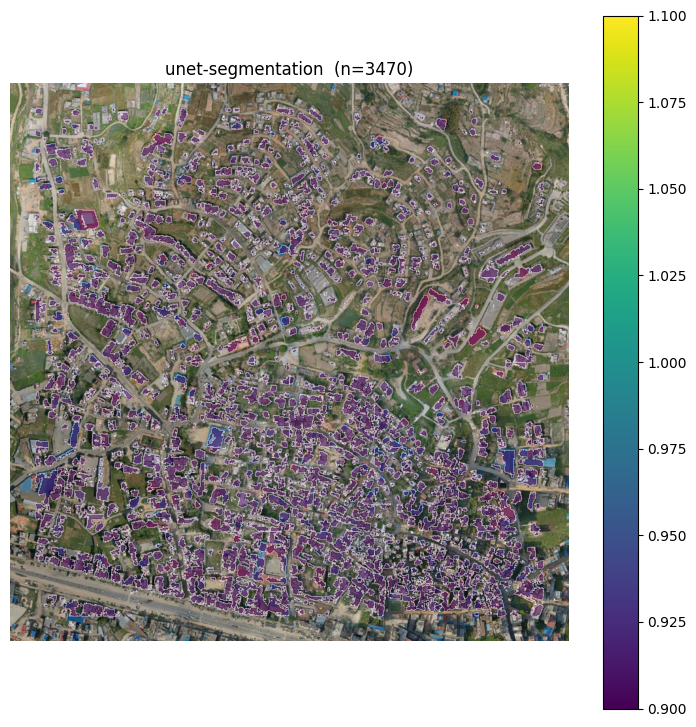

In [48]:
plot(gdf, "unet-segmentation")

## YOLO11n detection

In [49]:
gdf = call_predict(
    "1e398477-2472-46ea-9286-cd89411e1c32",
    collection="local-models",
    params={"confidence_threshold": 0.3, "iou_threshold": 0.45},
)
print(f"features: {len(gdf)}")
gdf.head()

HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/local-models/items/1e398477-2472-46ea-9286-cd89411e1c32 "HTTP/1.1 200 OK"
HTTP Request: GET https://stac.fair.krschap.tech/stac/collections/base-models/items/yolo11n-detection "HTTP/1.1 200 OK"
HTTP Request: POST https://yolo11n-detection.predict.fair.krschap.tech/predict "HTTP/1.1 200 OK"
features: 1492


,geometry,confidence,class,source
0,"POLYGON ((85.51651 27.63756, 85.51666 27.63756...",0.7854,0,OAM-193343-110117-18.tif
1,"POLYGON ((85.51641 27.63781, 85.51658 27.63781...",0.7786,0,OAM-193343-110117-18.tif
2,"POLYGON ((85.5162 27.63852, 85.51632 27.63852,...",0.6746,0,OAM-193343-110117-18.tif
3,"POLYGON ((85.51692 27.63782, 85.51704 27.63782...",0.6550,0,OAM-193343-110117-18.tif
4,"POLYGON ((85.51637 27.63746, 85.51646 27.63746...",0.6469,0,OAM-193343-110117-18.tif


<Axes: title={'center': 'yolo11n-detection  (n=1492)'}>

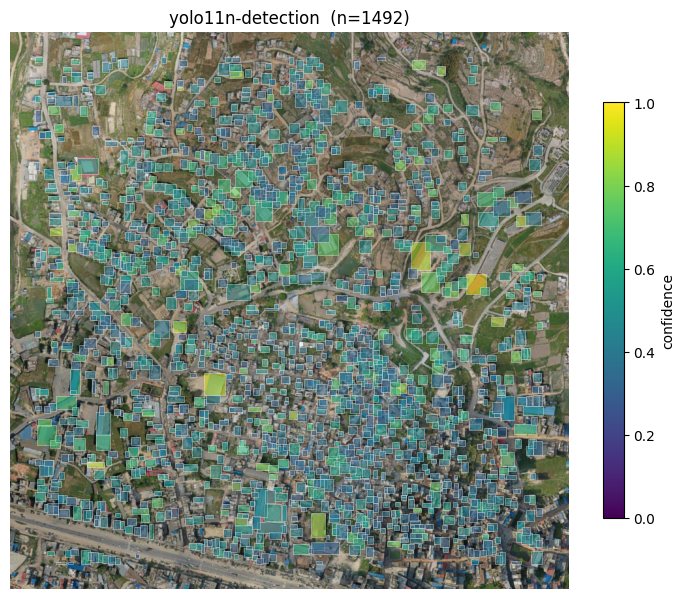

In [50]:
plot(gdf, "yolo11n-detection")